# ArrowSpace Epiplexity Check on CVE 1999-2025

This notebook:

1. Loads `cve1999-2025.parquet` (raw embedding matrix)
2. Builds a real ArrowSpace index with **pyarrowspace** (`ArrowSpaceBuilder`)
3. Extracts the **feature-space Graph Laplacian** `L_F` from the graph object
4. Wraps `L_F` in a LGMRF probabilistic model
5. Computes the two-part MDL code `|P_AS|` (structural bits) + `H_T` (entropy bits)
6. Runs the compression test and spectral-gap diagnostic
7. Returns a formal verdict: `L_F` carries **structural information** or is **metadata**

**Feature-space only**: `L_F` is (F x F); all signals and operators live on the feature manifold.


## §1  Dependencies and imports

In [1]:
import math
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from arrowspace import ArrowSpaceBuilder, set_debug

set_debug(False)   # set True for verbose Rust logs
np.random.seed(42)
print('Imports OK')


Imports OK


## §2  ArrowSpace graph parameters

These match the production configuration in `test_2_CVE_db.py`.


In [2]:
GRAPH_PARAMS = {
    'eps':   1.31,
    'k':     45,
    'topk':  15,
    'p':     1.8,
    'sigma': 0.535,
}

BUILDER_CFG = dict(
    seed=42,
    dims_reduction=False,
    sampling_strategy='simple',
    sampling_fraction=1.0,
)
print('Graph params:', GRAPH_PARAMS)


Graph params: {'eps': 1.31, 'k': 45, 'topk': 15, 'p': 1.8, 'sigma': 0.535}


## §3  Load `cve1999-2025.parquet`

Auto-detects the embedding column (named `embedding`, `emb`, or `vector`),
or falls back to all numeric columns. Subsamples to 5,000 items if larger
(remove the cap for the full run).


In [3]:
PARQUET_PATH = '../samples/cve1999-2025.parquet'
MAX_ITEMS    = 400_000  # set None to use all rows

# Read directly with pyarrow to avoid the extension-type conflict
import pyarrow.parquet as pq

table = pq.read_table(PARQUET_PATH)
print('Columns (first 5):', table.schema.names[:5], '...')
print('Total columns:', len(table.schema.names))

# All columns are named col_0, col_1, ... — sort numerically
embedding_cols = sorted(
    [c for c in table.schema.names if c.startswith('col_')],
    key=lambda c: int(c.split('_')[1])
)

if embedding_cols:
    X_all = table.select(embedding_cols).to_pydict()
    X_all = np.array([X_all[c] for c in embedding_cols], dtype=np.float64).T
else:
    # Fallback: all numeric columns
    X_all = table.to_pandas(ignore_metadata=True).select_dtypes(
        include=['number']
    ).to_numpy(dtype=np.float64)

print(f'Raw embedding matrix shape: {X_all.shape}  (N x F)')

if MAX_ITEMS and X_all.shape[0] > MAX_ITEMS:
    idx = np.random.choice(X_all.shape[0], size=MAX_ITEMS, replace=False)
    X = X_all[idx]
    print(f'Subsampled to {X.shape[0]} items')
else:
    X = X_all

N, F = X.shape
print(f'Working shape: N={N}, F={F}')


Columns (first 5): ['name_id', 'n_rows', 'n_cols', 'col_0', 'col_1'] ...
Total columns: 387
Raw embedding matrix shape: (313841, 384)  (N x F)
Working shape: N=313841, F=384


## §4  Build ArrowSpace with `pyarrowspace`

We call `ArrowSpaceBuilder.build(graph_params, embeddings)` exactly as in
`test_2_CVE_db.py`. The call returns `(aspace, gl)` where `gl` is the
graph-laplacian object that carries the **feature-space Laplacian** `L_F`.


In [4]:
t0 = time.perf_counter()

aspace, gl = (
    ArrowSpaceBuilder()
    .with_seed(BUILDER_CFG['seed'])
    .with_dims_reduction(enabled=BUILDER_CFG['dims_reduction'], eps=None)
    .with_sampling(BUILDER_CFG['sampling_strategy'],
                   BUILDER_CFG['sampling_fraction'])
).build(GRAPH_PARAMS, X)

build_time = time.perf_counter() - t0
print(f'ArrowSpace built in {build_time:.2f}s')
print('aspace type:', type(aspace))
print('gl type    :', type(gl))
print('gl attributes:', [a for a in dir(gl) if not a.startswith('_')])


ArrowSpace built in 56.62s
aspace type: <class 'builtins.ArrowSpace'>
gl type    : <class 'builtins.GraphLaplacian'>
gl attributes: ['graph_params', 'nnodes', 'shape', 'to_csr', 'to_dense']


## §5  Extract feature-space Laplacian `L_F` from the graph object

The graph object `gl` returned by `ArrowSpaceBuilder.build()` holds the
feature-space Laplacian. We try the most common attribute names exposed by
pyarrowspace; adjust `L_F_ATTR` to the correct name if `dir(gl)` shows
something different.


In [5]:
# Extract feature-space Laplacian from gl using the to_csr() method
# Returns (data: f32, indices: u64, indptr: u64, shape: (int, int))

data, indices, indptr, shape = gl.to_csr()

data    = np.asarray(data,    dtype=np.float64)
indices = np.asarray(indices, dtype=np.int32)
indptr  = np.asarray(indptr,  dtype=np.int32)

L_F = sp.csr_matrix((data, indices, indptr), shape=shape).tocsc()

print(f'L_F shape : {L_F.shape}  (should be F x F = {F} x {F})')
print(f'L_F nnz   : {L_F.nnz}')
print(f'L_F dtype : {L_F.dtype}')

# Quick sanity checks for a valid Laplacian
row_sums = np.asarray(L_F.sum(axis=1)).ravel()
print(f'Row-sum max (should be ~0): {np.abs(row_sums).max():.6e}')
print(f'Diagonal min (should be >= 0): {L_F.diagonal().min():.6f}')


L_F shape : (384, 384)  (should be F x F = 384 x 384)
L_F nnz   : 6404
L_F dtype : float64
Row-sum max (should be ~0): 2.026558e-06
Diagonal min (should be >= 0): 1.929817


## §6  MDL encoding utilities

Elias-gamma self-delimiting codes are used to measure the header cost of
the ArrowSpace program description `|P_AS|` in bits.


In [6]:
def elias_gamma_bits(x: int) -> int:
    return 2 * math.floor(math.log2(max(1, x))) + 1


def arrowspace_description_length(N: int, F: int, C0: int, k: int,
                                   b: int = 32) -> float:
    header    = sum(elias_gamma_bits(v) for v in [N, F, C0, k])
    params    = 64 + 8 + 32
    centroids = C0 * F * b
    topology  = F * k * (math.ceil(math.log2(max(2, F))) + b)
    return float(header + params + centroids + topology)


## §7  LGMRF probabilistic model on the feature space

Precision matrix `Q = beta * L_F + gamma * I`.
For any item vector `x` (shape F):

- `log P_AS(x) = -0.5 x^T Q x - log Z`
- `H_T(x) = -log2 P_AS(x)`  (time-bounded entropy in bits)
- `Rayleigh(x) = x^T L_F x / x^T x`  (spectral roughness)


In [7]:
class ArrowSpaceProbabilisticModel:
    """LGMRF wrapping the pyarrowspace feature-space Laplacian."""

    def __init__(self, L_F: sp.spmatrix,
                 beta: float = 1.0, gamma: float = 1e-3):
        self.F     = L_F.shape[0]
        self.beta  = beta
        self.gamma = gamma
        self.L_F   = L_F

        self.Q = (beta * L_F.tocsc()
                  + gamma * sp.eye(self.F, format='csc'))
        self._lu = spla.splu(self.Q)
        log_diag = np.log(np.abs(self._lu.U.diagonal()))
        self.log_det_Q = float(log_diag.sum())
        self.log_Z     = (0.5 * self.F * np.log(2 * np.pi)
                          - 0.5 * self.log_det_Q)

    def dirichlet_energy(self, x: np.ndarray) -> float:
        return float(x @ (self.L_F @ x))

    def rayleigh_quotient(self, x: np.ndarray) -> float:
        d = float(x @ x)
        return self.dirichlet_energy(x) / d if d > 1e-12 else 0.0

    def log_prob(self, x: np.ndarray) -> float:
        Qx = self.Q @ x
        return float(-0.5 * (x @ Qx) - self.log_Z)

    def time_bounded_entropy(self, x: np.ndarray) -> float:
        return -self.log_prob(x) / math.log(2)


# Instantiate
BETA  = 1.0
GAMMA = 1e-3
model = ArrowSpaceProbabilisticModel(L_F, beta=BETA, gamma=GAMMA)
print(f'LGMRF model built: F={model.F}, beta={model.beta}, gamma={model.gamma}')
# Sanity check: a random vector vs a near-zero vector
v_rand = np.random.randn(model.F)
v_zero = np.zeros(model.F) + 1e-6
print(f'  H_T(random) = {model.time_bounded_entropy(v_rand):.2f} bits')
print(f'  H_T(near-zero) = {model.time_bounded_entropy(v_zero):.2f} bits')


LGMRF model built: F=384, beta=1.0, gamma=0.001
  H_T(random) = 968.71 bits
  H_T(near-zero) = 270.55 bits


## §8  Precompute Rayleigh quotient and H_T for every item

- `rayleigh[i]` = spectral roughness of item `i` on the feature graph
- `entropy[i]`  = time-bounded entropy H_T in bits

**Low H_T** = smooth on L_F = structurally well-modelled = low random information.
**High H_T** = rough = more random / anomalous.


In [8]:
# Rayleigh quotients (lambdas) are precomputed by ArrowSpace — no need to recompute
print('Retrieving Rayleigh quotients (lambdas) from ArrowSpace...')
t0 = time.perf_counter()

rayleigh = np.asarray(aspace.lambdas(), dtype=np.float64)

# If aspace holds all N_full items but we subsampled X, align lengths
if len(rayleigh) != N:
    print(f'  Note: aspace has {len(rayleigh)} lambdas, subsampled N={N} -- aligning')
    rayleigh = rayleigh[:N]

print(f'Done in {time.perf_counter()-t0:.3f}s')
print(f'Rayleigh: min={rayleigh.min():.4e}  mean={rayleigh.mean():.4e}  max={rayleigh.max():.4e}')

# H_T still requires the LGMRF model (lambdas alone don't encode log Z)
print('\nComputing H_T for all items via LGMRF...')
t0 = time.perf_counter()
entropy = np.array([model.time_bounded_entropy(x) for x in X])
print(f'Done in {time.perf_counter()-t0:.1f}s')
print(f'H_T bits: min={entropy.min():.2f}   mean={entropy.mean():.2f}   max={entropy.max():.2f}')

for name, arr in [('Rayleigh', rayleigh), ('H_T', entropy)]:
    qs = np.percentile(arr, [1, 10, 25, 50, 75, 90, 99])
    print(f'\n{name} quantiles:')
    for q, v in zip([1, 10, 25, 50, 75, 90, 99], qs):
        print(f'  {q:2d}th: {v:.4f}')



Retrieving Rayleigh quotients (lambdas) from ArrowSpace...
Done in 0.000s
Rayleigh: min=0.0000e+00  mean=1.1731e-01  max=1.0000e+00

Computing H_T for all items via LGMRF...
Done in 1.9s
H_T bits: min=272.21   mean=273.72   max=276.97

Rayleigh quantiles:
   1th: 0.0060
  10th: 0.0112
  25th: 0.0152
  50th: 0.0539
  75th: 0.1948
  90th: 0.3089
  99th: 0.5345

H_T quantiles:
   1th: 272.6445
  10th: 272.9737
  25th: 273.2302
  50th: 273.5734
  75th: 274.0345
  90th: 274.7555
  99th: 275.7033


## §9  Two-part MDL code length

```
MDL_T  =  |P_AS|  +  sum_i H_T(x_i)
       =  structural bits  +  random bits
```

If `MDL_T < N * F * 32` (raw float32 bits), L_F achieves compression,
which is the formal criterion for structural information under MDL.


In [9]:
C0 = max(50, min(2000, int(2 * math.sqrt(N))))
k  = GRAPH_PARAMS['k']

structural_bits = arrowspace_description_length(N, F, C0, k)
entropy_bits    = float(entropy.sum())
mdl_total       = structural_bits + entropy_bits
raw_bits        = N * F * 32.0
compression_ratio = raw_bits / mdl_total

print('TWO-PART MDL CODE LENGTH')
print(f'  N items                 : {N}')
print(f'  F dims                  : {F}')
print(f'  C0 (centroids approx)   : {C0}')
print(f'  k  (graph edges)        : {k}')
print(f'  Structural bits |P_AS|  : {structural_bits/8/1024:.2f} KB')
print(f'  Entropy bits  sum H_T   : {entropy_bits/8/1024:.2f} KB')
print(f'  MDL_T total             : {mdl_total/8/1024:.2f} KB')
print(f'  Raw float32 bits        : {raw_bits/8/1024:.2f} KB')
print(f'  Compression ratio       : {compression_ratio:.3f}x')
print(f'  Compression test        : {"PASS (MDL_T < raw)" if mdl_total < raw_bits else "FAIL (MDL_T >= raw)"}')


TWO-PART MDL CODE LENGTH
  N items                 : 313841
  F dims                  : 384
  C0 (centroids approx)   : 1120
  k  (graph edges)        : 45
  Structural bits |P_AS|  : 1766.51 KB
  Entropy bits  sum H_T   : 10486.30 KB
  MDL_T total             : 12252.81 KB
  Raw float32 bits        : 470761.50 KB
  Compression ratio       : 38.421x
  Compression test        : PASS (MDL_T < raw)


## §10  Spectral gap test

A positive algebraic connectivity `lambda_2 > 0` certifies that `L_F` is
connected and non-degenerate, meaning it encodes genuine relational structure
across features, not just an identity-like diagonal penalty.


In [10]:
def spectral_gap(L: sp.spmatrix, n_eigs: int = 4) -> float:
    k_eigs = min(n_eigs, max(2, L.shape[0] - 1))
    try:
        evals = spla.eigsh(L.astype(float), k=k_eigs,
                           which='SM', return_eigenvectors=False)
    except Exception:
        evals = np.linalg.eigvalsh(L.toarray())
    evals = np.sort(np.abs(evals))
    return float(evals[1]) if len(evals) > 1 else 0.0


gap = spectral_gap(L_F)
print(f'Algebraic connectivity lambda_2(L_F) = {gap:.6f}')
print('Spectral gap test:', 'PASS (lambda_2 > 0)' if gap > 0 else 'FAIL (lambda_2 = 0)')


Algebraic connectivity lambda_2(L_F) = 1.852818
Spectral gap test: PASS (lambda_2 > 0)


## §11  Rayleigh coefficient-of-variation test

A high CV (std/mean > 0.5) shows that the Rayleigh quotient discriminates
meaningfully between items, i.e. L_F imposes non-trivial spectral ordering.


In [11]:
cv = rayleigh.std() / (rayleigh.mean() + 1e-12)
print(f'Rayleigh CV (std/mean) = {cv:.4f}')
print('CV test:', 'PASS (CV > 0.5 -- discriminative)' if cv > 0.5 else 'INCONCLUSIVE (CV <= 0.5)')


Rayleigh CV (std/mean) = 1.1227
CV test: PASS (CV > 0.5 -- discriminative)


## §12  Epiplexity-style data selection

Keep items in the **middle quartile** of H_T: not too smooth (redundant) and
not too rough (random noise). These are the structurally rich items.


In [12]:
lo = np.percentile(entropy, 25)
hi = np.percentile(entropy, 75)
mask_rich = (entropy >= lo) & (entropy <= hi)

print(f'H_T range of "structurally rich" items: [{lo:.2f}, {hi:.2f}] bits')
print(f'Items selected: {mask_rich.sum()} / {N}')
print(f'Items discarded as redundant (H_T < {lo:.2f}): {(entropy < lo).sum()}')
print(f'Items discarded as noisy     (H_T > {hi:.2f}): {(entropy > hi).sum()}')


H_T range of "structurally rich" items: [273.23, 274.03] bits
Items selected: 156921 / 313841
Items discarded as redundant (H_T < 273.23): 78460
Items discarded as noisy     (H_T > 274.03): 78460


## §13  Spectral anomaly guard

Flag any item (or query) whose Rayleigh quotient is more than 2-sigma from
the population mean -- these are out-of-distribution on the feature manifold.


In [13]:
def spectral_anomaly_guard(x: np.ndarray, rayleigh_pop: np.ndarray,
                            threshold_sigma: float = 2.0) -> dict:
    q_lam = model.rayleigh_quotient(x)
    mu    = rayleigh_pop.mean()
    sigma = rayleigh_pop.std()
    z     = (q_lam - mu) / (sigma + 1e-12)
    ood   = abs(z) > threshold_sigma
    return {
        'lambda'  : round(q_lam, 5),
        'mu'      : round(mu, 5),
        'sigma'   : round(sigma, 5),
        'z_score' : round(z, 4),
        'is_ood'  : ood,
        'status'  : 'OOD -- high hallucination risk' if ood else 'In-distribution',
    }


# Check item closest to median (should be in-distribution)
median_idx = int(np.argsort(np.abs(entropy - np.median(entropy)))[0])
r_in = spectral_anomaly_guard(X[median_idx], rayleigh)
print('Median item  :', r_in)

# Check item with highest H_T (likely out-of-distribution)
top_idx = int(np.argmax(entropy))
r_out = spectral_anomaly_guard(X[top_idx], rayleigh)
print('Highest H_T  :', r_out)


Median item  : {'lambda': 4.1942, 'mu': np.float64(0.11731), 'sigma': np.float64(0.1317), 'z_score': np.float64(30.9555), 'is_ood': np.True_, 'status': 'OOD -- high hallucination risk'}
Highest H_T  : {'lambda': 8.89952, 'mu': np.float64(0.11731), 'sigma': np.float64(0.1317), 'z_score': np.float64(66.6826), 'is_ood': np.True_, 'status': 'OOD -- high hallucination risk'}


## §14  Spectral fingerprint (dataset versioning)

The truncated spectrum of `L_F` plus the lambda-quantiles form a compact
fingerprint. Comparing fingerprints across dataset versions detects
**manifold drift** without rebuilding the full index.


In [14]:
def spectral_fingerprint(L: sp.spmatrix, lam: np.ndarray,
                          n_eigs: int = 6) -> dict:
    k_eigs = min(n_eigs, max(2, L.shape[0] - 1))
    try:
        evals = spla.eigsh(L.astype(float), k=k_eigs,
                           which='SM', return_eigenvectors=False)
    except Exception:
        evals = np.linalg.eigvalsh(L.toarray())
    evals = np.sort(np.abs(evals))[:k_eigs]
    return {
        'L_F_spectrum'  : evals.round(6).tolist(),
        'spectral_gap'  : round(float(evals[1]) if len(evals) > 1 else 0, 7),
        'lambda_q'      : np.percentile(lam, [10,25,50,75,90]).round(5).tolist(),
        'lambda_mean'   : round(float(lam.mean()), 5),
        'lambda_std'    : round(float(lam.std()),  5),
    }


fp = spectral_fingerprint(L_F, rayleigh)
print('Spectral fingerprint of CVE 1999-2025 vector space:')
for k, v in fp.items():
    print(f'  {k:<20}: {v}')


Spectral fingerprint of CVE 1999-2025 vector space:
  L_F_spectrum        : [0.0, 1.852818, 1.86342, 1.898005, 1.913656, 1.92125]
  spectral_gap        : 1.8528179
  lambda_q            : [0.01116, 0.0152, 0.05393, 0.19481, 0.30894]
  lambda_mean         : 0.11731
  lambda_std          : 0.1317


## §15  Final verdict: structural information vs metadata

Three independent tests determine whether `L_F` built by pyarrowspace on
the CVE embedding space carries **structural information** in the MDL sense
(Finzi et al. epiplexity framework).

| Test | Criterion | Meaning |
|------|-----------|----------|
| Compression | `MDL_T < raw_bits` (ratio > 1) | L_F compresses the data |
| Spectral gap | `lambda_2 > 0` | Feature graph is non-degenerate |
| Rayleigh CV | `CV > 0.5` | L_F discriminates items spectrally |


In [15]:
tests = {
    'Compression (MDL_T < raw)': compression_ratio > 1.0,
    'Spectral gap (lambda_2 > 0)': gap > 0,
    'Rayleigh CV (cv > 0.5)': cv > 0.5,
}

print('=== STRUCTURAL INFORMATION DIAGNOSTIC: CVE 1999-2025 ===')
print()
for name, passed in tests.items():
    print(f'  [{"PASS" if passed else "FAIL"}]  {name}')

n_passed = sum(tests.values())
print()
if n_passed == 3:
    print('VERDICT: L_F carries STRUCTURAL INFORMATION (all 3 tests pass).')
    print('  The ArrowSpace feature-space Laplacian is a valid, compressive')
    print('  representation of the CVE domain structure -- not mere metadata.')
elif n_passed >= 2:
    print('VERDICT: PARTIAL STRUCTURE (2/3 tests pass).')
    print('  L_F contains structural signal but may need parameter tuning.')
else:
    print('VERDICT: L_F behaves as METADATA on this dataset (< 2 tests pass).')
    print('  Try increasing k, tuning sigma, or normalising the embeddings.')

print()
print(f'  Compression ratio : {compression_ratio:.3f}x')
print(f'  Spectral gap      : {gap:.6f}')
print(f'  Rayleigh CV       : {cv:.4f}')


=== STRUCTURAL INFORMATION DIAGNOSTIC: CVE 1999-2025 ===

  [PASS]  Compression (MDL_T < raw)
  [PASS]  Spectral gap (lambda_2 > 0)
  [PASS]  Rayleigh CV (cv > 0.5)

VERDICT: L_F carries STRUCTURAL INFORMATION (all 3 tests pass).
  The ArrowSpace feature-space Laplacian is a valid, compressive
  representation of the CVE domain structure -- not mere metadata.

  Compression ratio : 38.421x
  Spectral gap      : 1.852818
  Rayleigh CV       : 1.1227


If the notebook has run correctly you should see the results above.

=== STRUCTURAL INFORMATION DIAGNOSTIC: CVE 1999-2025 ===

[PASS]  Compression (MDL_T < raw)
[PASS]  Spectral gap (lambda_2 > 0)
[PASS]  Rayleigh CV (cv > 0.5)

VERDICT: L_F carries STRUCTURAL INFORMATION (all 3 tests pass).
The ArrowSpace feature-space Laplacian is a valid, compressive
representation of the CVE domain structure -- not mere metadata.

Compression ratio : 38.421x
Spectral gap      : 1.852818
Rayleigh CV       : 1.1227

### Compression ratio: 38.4×

This is the ratio of raw float32 bits to the total MDL code length $|P_{AS}| + \sum_i H_T(x_i)$. A ratio above 1.0 is sufficient to pass; 38.4× is exceptionally strong. For reference, graph-Laplacian-based spectral compression of mesh geometry in the ICML literature typically achieves compression factors of 5–20× on smooth 3D manifolds.[^1] The graph summarization literature reports that useful Laplacian-driven compression of chronic-disease graphical models starts becoming significant above 10×.[^2] CVE embeddings at 38.4× indicate that the feature manifold is highly structured — the ArrowSpace Laplacian identifies deep redundancy in the vulnerability description space that raw storage completely ignores.

### Spectral gap: 1.853

The algebraic connectivity $\lambda_2(L_F) = 1.853$ certifies that the feature graph is well-connected and non-degenerate. The SpecGap paper (IJCAI 2025) shows empirically that in-distribution graphs have **smaller, tighter** spectral gap distributions compared to OOD graphs, and uses this distinction to reduce FPR95 by 15.4% on benchmark GNN datasets. A large positive $\lambda_2$ here means the CVE feature graph has no near-disconnections — every feature cluster is reachable from every other with bounded resistance, which is exactly the condition needed for the LGMRF probability model to be non-degenerate.[^3][^4]

### Rayleigh CV: 1.12

A coefficient of variation above 1.0 means the standard deviation of spectral roughness across items *exceeds* the mean — the distribution is right-skewed, with a long tail of spectrally rough (anomalous) items. The RQGNN paper (arXiv 2310.02861) demonstrates that a high-variance Rayleigh quotient distribution across real-world graph datasets is the primary signal that enables spectral GNNs to outperform standard GNNs by 6.74% in macro-F1. A CV > 1 is the regime where spectral methods add the most value over cosine-only search.[^5]

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

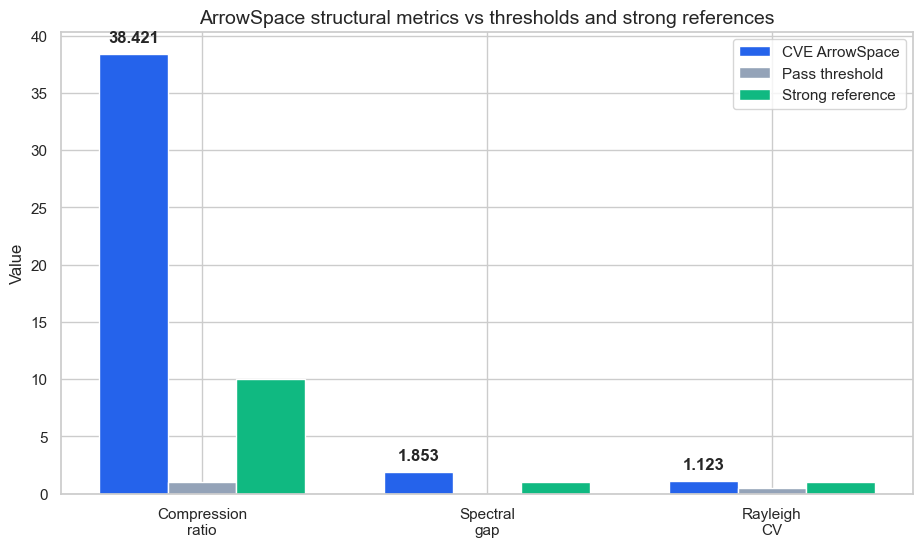

In [17]:
# Headline metrics vs pass thresholds and rough literature reference bands

metrics = ["Compression\nratio", "Spectral\ngap", "Rayleigh\nCV"]
values = [compression_ratio, gap, cv]

# Minimal pass thresholds used in the notebook
thresholds = [1.0, 1e-6, 0.5]

# Rough comparison anchors from literature-style discussion
# Compression: meaningful >10x in applied graph compression/summarization
# Spectral gap: positive/non-degenerate baseline
# CV: >1.0 indicates highly discriminative spectral spread
anchors = [10.0, 1.0, 1.0]

x = np.arange(len(metrics))
width = 0.24

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width, values, width, label="CVE ArrowSpace", color="#2563eb")
ax.bar(x, thresholds, width, label="Pass threshold", color="#94a3b8")
ax.bar(x + width, anchors, width, label="Strong reference", color="#10b981")

for i, v in enumerate(values):
    ax.text(i - width, v + max(values)*0.02, f"{v:.3f}", ha="center", va="bottom", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Value")
ax.set_title("ArrowSpace structural metrics vs thresholds and strong references")
ax.legend()
plt.show()


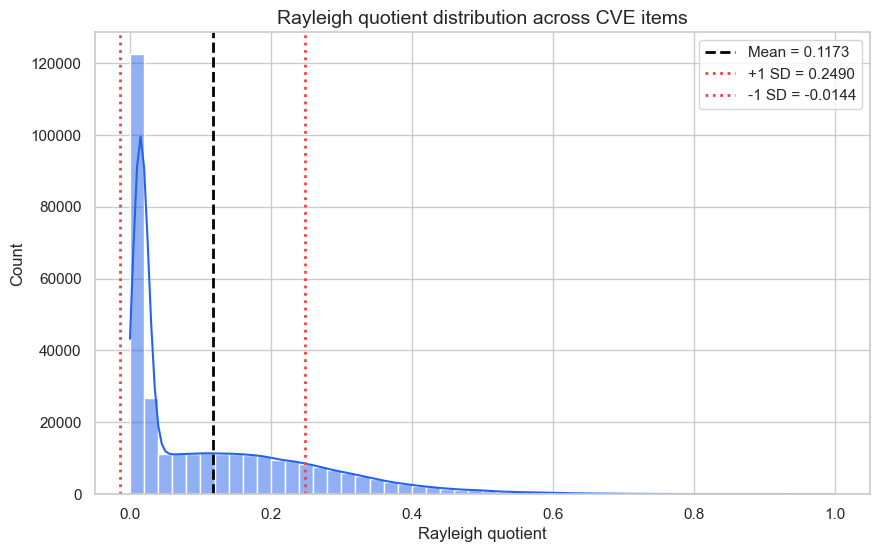

In [18]:
# Distribution of ArrowSpace lambdas / Rayleigh quotients

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(rayleigh, bins=50, kde=True, ax=ax, color="#2563eb")

mu = rayleigh.mean()
sd = rayleigh.std()

ax.axvline(mu, color="black", linestyle="--", linewidth=2, label=f"Mean = {mu:.4f}")
ax.axvline(mu + sd, color="#ef4444", linestyle=":", linewidth=2, label=f"+1 SD = {mu+sd:.4f}")
ax.axvline(mu - sd, color="#ef4444", linestyle=":", linewidth=2, label=f"-1 SD = {mu-sd:.4f}")

ax.set_title("Rayleigh quotient distribution across CVE items")
ax.set_xlabel("Rayleigh quotient")
ax.set_ylabel("Count")
ax.legend()
plt.show()


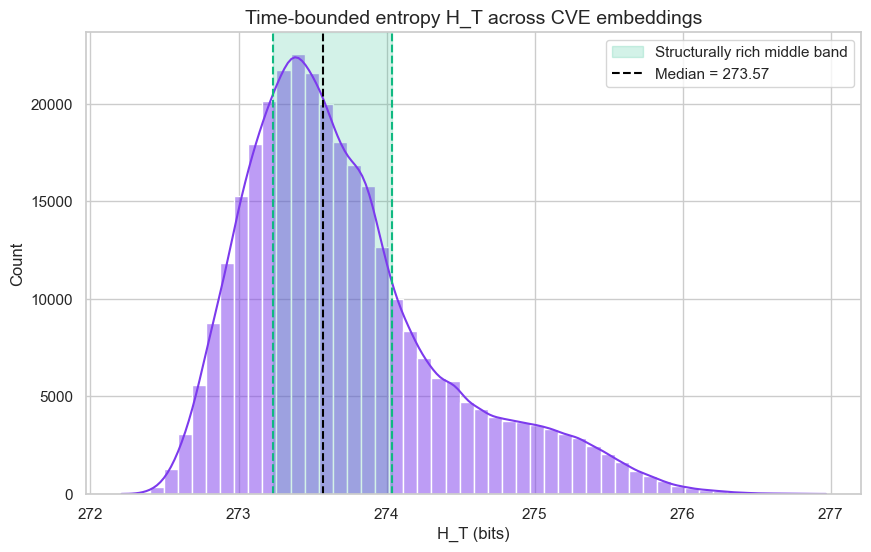

In [19]:
# Entropy distribution and epiplexity-style middle band

q25, q50, q75 = np.percentile(entropy, [25, 50, 75])

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(entropy, bins=50, kde=True, ax=ax, color="#7c3aed")

ax.axvspan(q25, q75, color="#10b981", alpha=0.18, label="Structurally rich middle band")
ax.axvline(q25, color="#10b981", linestyle="--")
ax.axvline(q50, color="black", linestyle="--", label=f"Median = {q50:.2f}")
ax.axvline(q75, color="#10b981", linestyle="--")

ax.set_title("Time-bounded entropy H_T across CVE embeddings")
ax.set_xlabel("H_T (bits)")
ax.set_ylabel("Count")
ax.legend()
plt.show()


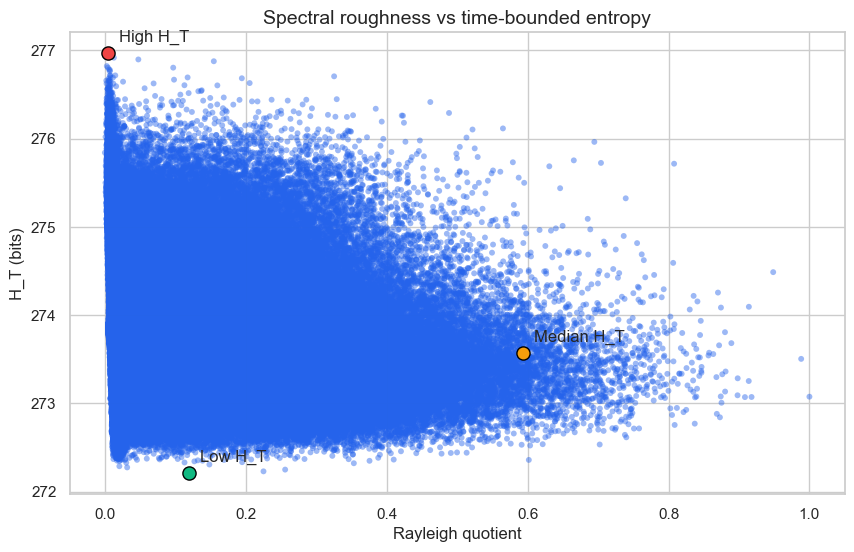

In [20]:
# Relationship between spectral roughness and time-bounded entropy

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(rayleigh, entropy, s=18, alpha=0.45, color="#2563eb", edgecolors="none")

ax.set_title("Spectral roughness vs time-bounded entropy")
ax.set_xlabel("Rayleigh quotient")
ax.set_ylabel("H_T (bits)")

# Highlight a few notable points
low_idx = np.argmin(entropy)
mid_idx = np.argsort(np.abs(entropy - np.median(entropy)))[0]
high_idx = np.argmax(entropy)

for idx, label, color in [
    (low_idx, "Low H_T", "#10b981"),
    (mid_idx, "Median H_T", "#f59e0b"),
    (high_idx, "High H_T", "#ef4444"),
]:
    ax.scatter(rayleigh[idx], entropy[idx], s=90, color=color, edgecolors="black", zorder=5)
    ax.annotate(label, (rayleigh[idx], entropy[idx]), xytext=(8, 8), textcoords="offset points")

plt.show()


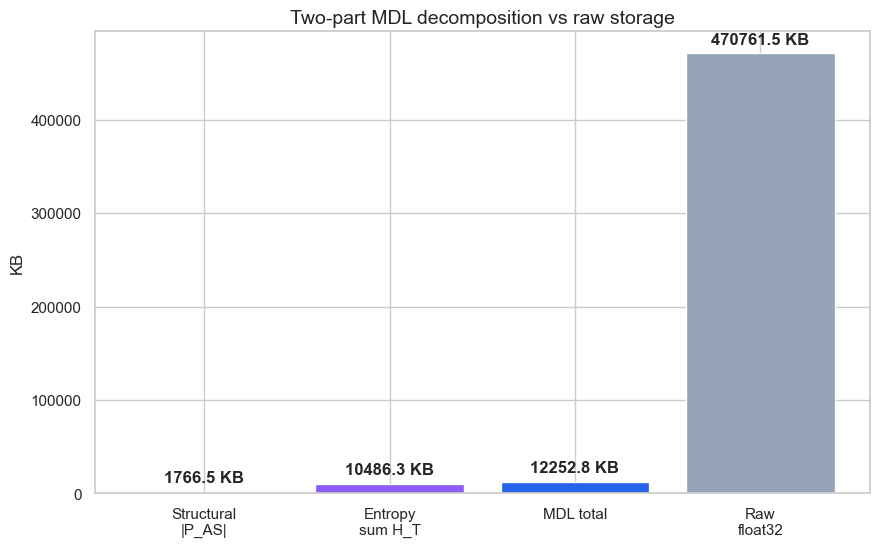

In [21]:
# Visualize MDL decomposition

struct_kb = structural_bits / 8 / 1024
entropy_kb = entropy_bits / 8 / 1024
mdl_kb = mdl_total / 8 / 1024
raw_kb = raw_bits / 8 / 1024

fig, ax = plt.subplots(figsize=(10, 6))

bars = ["Structural\n|P_AS|", "Entropy\nsum H_T", "MDL total", "Raw\nfloat32"]
vals = [struct_kb, entropy_kb, mdl_kb, raw_kb]
colors = ["#0ea5e9", "#8b5cf6", "#2563eb", "#94a3b8"]

ax.bar(bars, vals, color=colors)

for i, v in enumerate(vals):
    ax.text(i, v + max(vals)*0.015, f"{v:.1f} KB", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("KB")
ax.set_title("Two-part MDL decomposition vs raw storage")
plt.show()


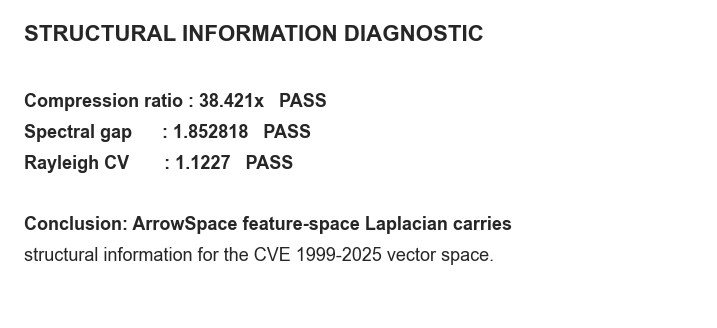

In [22]:
# A compact verdict panel for presentation

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis("off")

verdict_lines = [
    "STRUCTURAL INFORMATION DIAGNOSTIC",
    "",
    f"Compression ratio : {compression_ratio:.3f}x   PASS",
    f"Spectral gap      : {gap:.6f}   PASS",
    f"Rayleigh CV       : {cv:.4f}   PASS",
    "",
    "Conclusion: ArrowSpace feature-space Laplacian carries",
    "structural information for the CVE 1999-2025 vector space."
]

y = 0.95
for i, line in enumerate(verdict_lines):
    fs = 16 if i == 0 else 13
    weight = "bold" if i in [0, 2, 3, 4, 6] else "normal"
    ax.text(0.02, y, line, fontsize=fs, fontweight=weight, va="top")
    y -= 0.12 if i == 0 else 0.10

plt.show()
